In [1302]:
import numpy as np

def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))

n_quantiles = 256
state = 0
action = 0
new_state = 1
reward = lambda: np.random.normal(0, 1)
gamma = 0.99
learning_rate = 0.1

tau = ((2 * np.arange(n_quantiles) + 1) / (2.0 * n_quantiles))

def rho(u):
    return -np.abs(tau[:, None] - (u < 0))# * du_huber(u, 1.0)

theta = np.zeros((2, 1, n_quantiles), dtype=float)

In [1303]:
lr = learning_rate
for i in range(10_000):
    if i % 2_000 == 0:
        lr *= 0.5
    pred_quantiles = theta[state, action]
    greedy_action = theta[new_state].mean(1).argmax()
    target_quantiles = reward() + gamma * theta[new_state, greedy_action]

    u = target_quantiles[None, :] - pred_quantiles[:, None]
    grad = rho(u).mean(1)
    theta[state, action] -= lr * grad

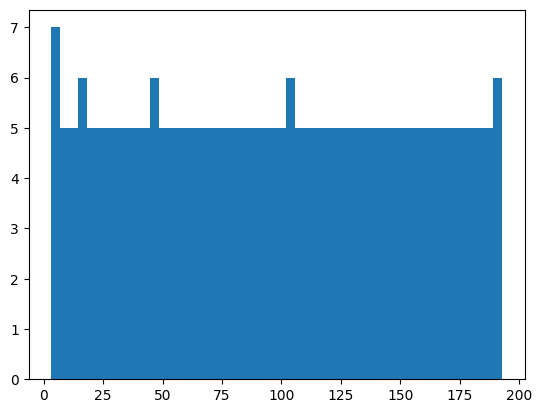

In [1304]:
from matplotlib import pyplot as plt

plt.hist(theta[state, action], 50);